In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
import urllib.request

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

urllib.request.urlretrieve(url, "sms_spam.zip")

print("Dataset downloaded successfully!")

Dataset downloaded successfully!


In [3]:
import zipfile

with zipfile.ZipFile("sms_spam.zip", "r") as zip_ref:
    zip_ref.extractall("sms_spam")

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [4]:
data = pd.read_csv(
    "sms_spam/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"]
)

print("Dataset loaded successfully!")
print("Dataset shape:", data.shape)

Dataset loaded successfully!
Dataset shape: (5572, 2)


In [5]:
data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB


In [7]:
print(data["label"].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


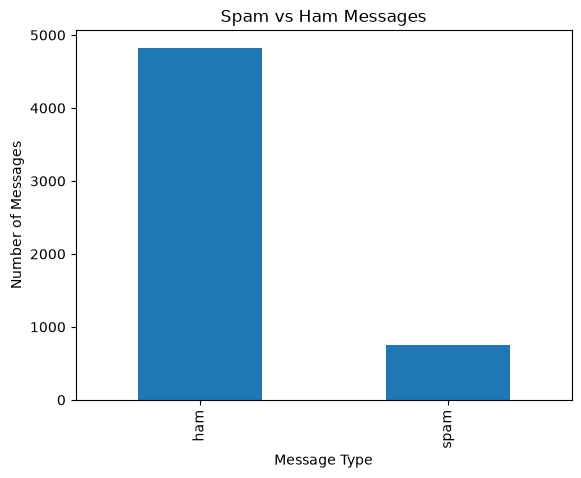

In [8]:
data["label"].value_counts().plot(
    kind="bar",
    title="Spam vs Ham Messages"
)

plt.xlabel("Message Type")
plt.ylabel("Number of Messages")
plt.show()

In [9]:
data["label"] = data["label"].map({
    "ham": 0,
    "spam": 1
})

data.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [10]:
X = data["message"]
y = data["label"]

print("Input shape:", X.shape)
print("Output shape:", y.shape)

Input shape: (5572,)
Output shape: (5572,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training messages:", len(X_train))
print("Testing messages:", len(X_test))

Training messages: 4457
Testing messages: 1115


In [12]:
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF conversion completed!")
print("Training feature shape:", X_train_tfidf.shape)

TF-IDF conversion completed!
Training feature shape: (4457, 7403)


In [13]:
model = MultinomialNB()

print("Naive Bayes model created!")

Naive Bayes model created!


In [14]:
model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [15]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed!")

Prediction completed!


In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", round(accuracy * 100, 2), "%")

Accuracy: 0.9704035874439462
Accuracy Percentage: 97.04 %


In [17]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Spam", "Spam"]
    )
)

              precision    recall  f1-score   support

    Not Spam       0.97      1.00      0.98       966
        Spam       1.00      0.78      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



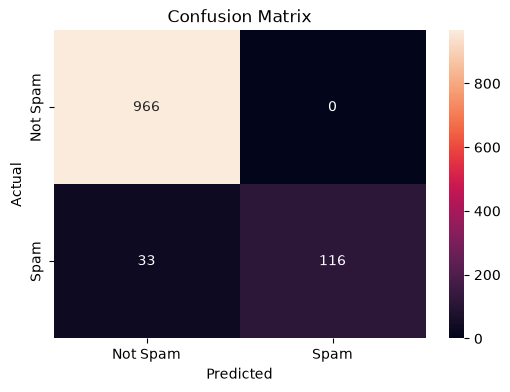

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Not Spam", "Spam"],
    yticklabels=["Not Spam", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [19]:
message = ["WINNER! You have won 1000000 dollars! Call now to claim your FREE prize!"]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("Result: SPAM")
else:
    print("Result: NOT SPAM")

Result: SPAM


In [20]:
message = ["Hi, please send me the notes for today's class."]

message_tfidf = vectorizer.transform(message)

prediction = model.predict(message_tfidf)

if prediction[0] == 1:
    print("Result: SPAM")
else:
    print("Result: NOT SPAM")

Result: NOT SPAM
